# Credit Risk Validation & Backtest — Real Freddie Mac Data

Everything built so far in the credit-risk module (`dbt/models/credit_risk/`)
proves the *mechanics* work — the SQL is correct, the tests pass, the
numbers are internally consistent. That's not the same as evidence the
**methodology** (vintage curves, roll-rate transition matrices) actually
forecasts real credit performance. This notebook closes that gap: it runs
the same techniques against a real, public loan-performance dataset with a
genuine time-based holdout, and reports how accurate the forecasts
actually were.

**Data**: Freddie Mac's Single-Family Loan-Level Dataset, 2021 vintage
sample (50,000 loans, `data/external/freddie_mac/`, gitignored — see that
folder's AGENTS.md). This is **mortgage** data, not credit cards — the
loss *levels* won't match Synchrony's card portfolio. What's being
validated is whether the vintage/roll-rate *methodology* forecasts
accurately on a real monthly loan-performance panel — that's the part
that transfers.

Read this end to end before discussing it in an interview — like the rest
of this module, it's written to double as review material, not just a
script that produces numbers.

In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)

PROJECT_ROOT = Path("/Users/trustanprice/Desktop/Personal/ledgerone")
ORIG = PROJECT_ROOT / "data/external/freddie_mac/loan_originations.parquet"
PERF = PROJECT_ROOT / "data/external/freddie_mac/loan_performance.parquet"

# Time-based split: everything up to TRAIN_CUTOFF fits the transition
# matrix; everything after is held out for comparison. See section 2 for
# why this must be time-based, not random.
TRAIN_CUTOFF = "2024-09-01"
HORIZON = 18  # months of holdout compared
SEVERE = ("90-119 DPD", "120+/Charged-Off")

con = duckdb.connect()
print("Data loaded from:", ORIG.name, "and", PERF.name)

Data loaded from: loan_originations.parquet and loan_performance.parquet


## 1. Ingestion & bucket mapping (recap)

`src/ingest_freddie_mac_validation_data.py` parses the raw pipe-delimited
files and maps them to this project's grain — see that script's docstring
for the full column-layout verification (fetched Freddie Mac's current,
January 2026 General User Guide directly, then cross-checked every field
this notebook uses against its actual value distribution across all
50,000 loans, not just its documented position).

**The bucket mapping is a modeling decision worth stating plainly**:
Freddie Mac's 2-digit delinquency status code (`'00'`=current, `'01'`=30-59
days, `'02'`=60-89, `'03'`=90-119, higher = more months delinquent, `'RA'`=REO
acquisition) maps onto this project's existing 5-bucket scheme the same
way the synthetic module's buckets work. Critically: **mortgages don't
"charge off" the way credit cards do** — there's no single event that
zeroes the balance. `120+/Charged-Off` here is a **serious-delinquency /
foreclosure-adjacent proxy for loss**, not a literal charge-off. That's a
real, explicit difference from the synthetic card module this notebook is
validating against — say so out loud if asked.

In [2]:
originations = con.execute(f"select * from read_parquet('{ORIG}')").df()
performance = con.execute(f"select * from read_parquet('{PERF}')").df()

print(f"Accounts: {len(originations):,}")
print(f"Performance rows: {len(performance):,}")
print(f"Performance window: {performance.performance_month.min().date()} - {performance.performance_month.max().date()}")
print(f"Months on book: {performance.months_on_book.min()} - {performance.months_on_book.max()}")
print()
print("Origination cohorts (by first-payment-date quarter):")
print(originations.origination_quarter.value_counts().sort_index())

Accounts: 50,000
Performance rows: 2,537,054
Performance window: 2021-01-01 - 2026-03-01
Months on book: 0 - 62

Origination cohorts (by first-payment-date quarter):
origination_quarter
2021-01-01     3729
2021-04-01    12823
2021-07-01    12216
2021-10-01    13277
2022-01-01     7947
2022-04-01        1
2022-07-01        3
2022-10-01        3
2023-01-01        1
Name: count, dtype: int64


Five cohorts have meaningful sample size (2021-Q1 through 2022-Q1,
3.7K-13.3K loans each); a handful of loans with a first-payment-date
quarter beyond that (a few loans whose closing straddled the 2021/2022
boundary) have single-digit counts and are excluded from the headline
backtest metrics below as statistically meaningless — noted here rather
than silently dropped.

In [3]:
REAL_COHORTS = [pd.Timestamp(x) for x in
                ["2021-01-01", "2021-04-01", "2021-07-01", "2021-10-01", "2022-01-01"]]
print("Cohorts used for the backtest:", [c.strftime('%Y-Q') + str((c.month-1)//3+1) for c in REAL_COHORTS])

Cohorts used for the backtest: ['2021-Q1', '2021-Q2', '2021-Q3', '2021-Q4', '2022-Q1']


## 2. Why a time-based split, not a random one

A **random** split (e.g. 80% of loan-months picked at random for training,
20% held out) would let the model see performance from *later* in a
loan's life while training on data that, chronologically, includes
information from *after* the holdout points it's being tested against.
That's leakage — the model would implicitly "know" how a loan turned out
before being asked to forecast it, which is exactly backwards from how
this model would actually be used in production (forecasting the future
from what's known *today*).

A **time-based** split — fit the matrix on data through a cutoff month,
forecast forward, compare against what actually happened after that
cutoff — is the only split that honestly answers "if I'd built this model
on what I knew as of the cutoff, how well would it have forecast what
actually happened next?" That's the real question a production model's
backtest has to answer.

In [4]:
cutoff_mob = con.execute(f'''
    select o.origination_quarter, date_diff('month', o.origination_quarter, date '{TRAIN_CUTOFF}') as cutoff_mob
    from read_parquet('{ORIG}') o
    where o.origination_quarter in ({",".join("'" + c.strftime('%Y-%m-%d') + "'" for c in REAL_COHORTS)})
    group by 1 order by 1
''').df()
print(f"Train cutoff: {TRAIN_CUTOFF}  |  Holdout horizon: {HORIZON} months")
print()
print("Months-on-book at cutoff, by cohort (this is where each cohort's holdout window starts):")
print(cutoff_mob)

Train cutoff: 2024-09-01  |  Holdout horizon: 18 months

Months-on-book at cutoff, by cohort (this is where each cohort's holdout window starts):
  origination_quarter  cutoff_mob
0          2021-01-01          44
1          2021-04-01          41
2          2021-07-01          38
3          2021-10-01          35
4          2022-01-01          32


## 3. Actual vintage curve (ground truth)

Same technique as `credit_risk__vintage_curves`: flag the first month each
account reaches severe delinquency (90+ DPD or worse), then accumulate —
cumulative sums/ratios over a partitioned, ordered window. This uses the
**full** performance history (train + holdout combined) since it's the
ground truth we'll compare predictions against, not something being
forecast itself.

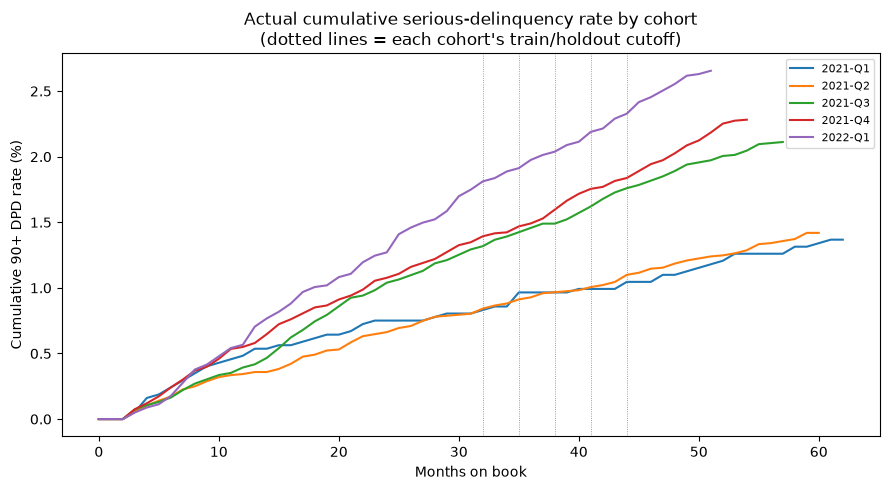

In [5]:
actual_curve = con.execute(f'''
    with perf as (
        select p.account_id, p.months_on_book, p.delinquency_bucket, o.origination_quarter
        from read_parquet('{PERF}') p join read_parquet('{ORIG}') o on p.account_id = o.account_id
    ),
    flagged as (
        select account_id, origination_quarter, months_on_book,
            case when delinquency_bucket in {SEVERE}
                 and months_on_book = min(case when delinquency_bucket in {SEVERE} then months_on_book end) over (partition by account_id)
                 then 1 else 0 end as is_first_90plus
        from perf
    ),
    monthly as (select origination_quarter, months_on_book, sum(is_first_90plus) as new_90plus from flagged group by 1,2),
    cohort_sizes as (select origination_quarter, count(distinct account_id) as n from read_parquet('{ORIG}') group by 1)
    select m.origination_quarter, m.months_on_book,
        sum(m.new_90plus) over (partition by m.origination_quarter order by m.months_on_book rows between unbounded preceding and current row) / c.n as actual_cum_90plus_rate,
        c.n as cohort_n
    from monthly m join cohort_sizes c on m.origination_quarter = c.origination_quarter
    order by 1,2
''').df()

fig, ax = plt.subplots(figsize=(9, 5))
for cohort in REAL_COHORTS:
    sub = actual_curve[actual_curve.origination_quarter == cohort]
    ax.plot(sub.months_on_book, sub.actual_cum_90plus_rate * 100, label=cohort.strftime('%Y-Q') + str((cohort.month-1)//3+1))
for cohort in REAL_COHORTS:
    cmob = int(cutoff_mob.loc[cutoff_mob.origination_quarter == cohort, 'cutoff_mob'].iloc[0])
    ax.axvline(cmob, color='gray', linestyle=':', linewidth=0.6)
ax.set_title("Actual cumulative serious-delinquency rate by cohort\n(dotted lines = each cohort's train/holdout cutoff)")
ax.set_xlabel("Months on book")
ax.set_ylabel("Cumulative 90+ DPD rate (%)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Fit the training-window transition matrix

Same LAG-based approach as `credit_risk__roll_rate_transition_matrix`,
restricted to `performance_month <= TRAIN_CUTOFF` — this is genuinely all
the model "knows" at forecast time.

**One simplification, stated explicitly**: for the *cumulative* forecast
in this notebook, 90-119 DPD and 120+/Charged-Off are collapsed into one
**absorbing** state, "90+". Once an account first reaches either, it's
already counted as a "reached serious delinquency" event for the
cumulative curve — what it does afterward (cure from 90-119 back to
60-89, progress to 120+, etc.) doesn't change that. This mirrors exactly
how `cumulative_90plus_rate` already works in `credit_risk__vintage_curves`
(a one-way ratchet, not a point-in-time snapshot) — the 4-state collapse
just makes that ratchet directly computable via a single Markov
roll-forward instead of needing separate first-passage-time bookkeeping.

In [6]:
train_matrix = con.execute(f'''
    with perf as (
        select account_id, months_on_book, performance_month,
            case when delinquency_bucket in {SEVERE} then '90+' else delinquency_bucket end as state4
        from read_parquet('{PERF}') where performance_month <= date '{TRAIN_CUTOFF}'
    ),
    lagged as (
        select account_id, state4, lag(state4) over (partition by account_id order by months_on_book) as prior_state4
        from perf
    ),
    transitions as (select prior_state4 as from_state, state4 as to_state from lagged where prior_state4 is not null and prior_state4 != '90+'),
    counted as (select from_state, to_state, count(*) as n from transitions group by 1,2)
    select from_state, to_state, n, n::double / sum(n) over (partition by from_state) as rate
    from counted order by from_state, to_state
''').df()

states = ["Current", "30-59 DPD", "60-89 DPD", "90+"]
P = pd.DataFrame(0.0, index=states, columns=states)
for _, r in train_matrix.iterrows():
    P.loc[r.from_state, r.to_state] = r.rate
P.loc["90+", "90+"] = 1.0  # absorbing

print("Training-window transition matrix (rows sum to 1):")
print(P.round(4))
print()
print("Row sums (sanity check):", P.sum(axis=1).round(4).values)

Training-window transition matrix (rows sum to 1):
           Current  30-59 DPD  60-89 DPD     90+
Current     0.9959     0.0040     0.0001  0.0001
30-59 DPD   0.5344     0.3235     0.1380  0.0041
60-89 DPD   0.2313     0.1131     0.2421  0.4135
90+         0.0000     0.0000     0.0000  1.0000

Row sums (sanity check): [1. 1. 1. 1.]


Read the **60-89 DPD** row: 41.3% chance of rolling into 90+ next
month, versus only 23.1% chance of curing all the way back to Current —
severity accelerates, exactly the shape a real roll-rate matrix should
have. The **Current** row is reassuringly boring: 99.6% stay current.

## 5. Roll the training matrix forward through the holdout window

Same Markov roll-forward `credit_risk__cecl_reserve_estimate` uses —
repeatedly multiply a probability distribution by the transition matrix,
one month at a time. Here, since "90+" is absorbing, `P(state = 90+ at
horizon h)` **is** `P(first reached 90+ by horizon h)` — no separate
bookkeeping needed, that's the payoff of the 4-state collapse above.

For each cohort, the accounts that had **already** reached 90+ by the
train cutoff are frozen in (their contribution to the cumulative rate
can't decrease). Everyone else gets rolled forward from *their actual
bucket at the cutoff* (Current / 30-59 / 60-89), split by starting bucket.

In [7]:
roll = {s: np.zeros(HORIZON + 1) for s in states}
for s in states:
    vec = pd.Series(0.0, index=states)
    vec[s] = 1.0
    roll[s][0] = vec["90+"]
    for h in range(1, HORIZON + 1):
        vec = vec @ P
        roll[s][h] = vec["90+"]
prob_absorbed = pd.DataFrame(roll)  # index = horizon month h, columns = starting state

# Bucket distribution at cutoff, restricted to accounts that have NEVER
# been severe as of cutoff -- NOT the same as "not currently severe," which
# would incorrectly include accounts that reached 90+ earlier and cured
# before the cutoff snapshot (a real bug caught while building this: it
# silently understated the "already reached" base rate and produced a
# systematic, misleading bias in the first draft of this analysis).
never_severe_state_at_cutoff = con.execute(f'''
    with perf as (
        select p.account_id, p.months_on_book, o.origination_quarter, p.delinquency_bucket
        from read_parquet('{PERF}') p join read_parquet('{ORIG}') o on p.account_id = o.account_id
    ),
    upto_cutoff as (
        select *, date_diff('month', origination_quarter, date '{TRAIN_CUTOFF}') as cutoff_mob
        from perf
        where months_on_book <= date_diff('month', origination_quarter, date '{TRAIN_CUTOFF}')
    ),
    ever_severe as (
        select account_id, max(case when delinquency_bucket in {SEVERE} then 1 else 0 end) as was_ever_severe
        from upto_cutoff group by 1
    ),
    latest as (
        select *, row_number() over (partition by account_id order by months_on_book desc) as rn
        from upto_cutoff
    )
    select l.origination_quarter, l.delinquency_bucket, count(*) as n
    from latest l join ever_severe e on l.account_id = e.account_id
    where l.rn = 1 and e.was_ever_severe = 0
    group by 1, 2
''').df()

rows = []
for cohort in REAL_COHORTS:
    cutoff = int(cutoff_mob.loc[cutoff_mob.origination_quarter == cohort, "cutoff_mob"].iloc[0])
    total_n = int(actual_curve.loc[actual_curve.origination_quarter == cohort, "cohort_n"].iloc[0])
    base_rate = actual_curve.loc[(actual_curve.origination_quarter == cohort) & (actual_curve.months_on_book == cutoff), "actual_cum_90plus_rate"].iloc[0]
    sub = never_severe_state_at_cutoff[never_severe_state_at_cutoff.origination_quarter == cohort]
    bucket_n = dict(zip(sub.delinquency_bucket, sub.n))
    for h in range(1, HORIZON + 1):
        mob = cutoff + h
        pred = base_rate
        for b in ["Current", "30-59 DPD", "60-89 DPD"]:
            pred += (bucket_n.get(b, 0) / total_n) * prob_absorbed.loc[h, b]
        actual_row = actual_curve[(actual_curve.origination_quarter == cohort) & (actual_curve.months_on_book == mob)]
        if len(actual_row) == 0:
            continue
        rows.append({
            "cohort": cohort, "months_on_book": mob, "horizon_month": h,
            "predicted": pred, "actual": actual_row.actual_cum_90plus_rate.iloc[0], "cohort_n": total_n,
        })

results = pd.DataFrame(rows)
results["abs_err"] = (results.predicted - results.actual).abs()
results["ape"] = results.abs_err / results.actual.replace(0, np.nan)
print(f"Comparison points: {len(results)} (5 cohorts x up to {HORIZON} holdout months)")

Comparison points: 90 (5 cohorts x up to 18 holdout months)


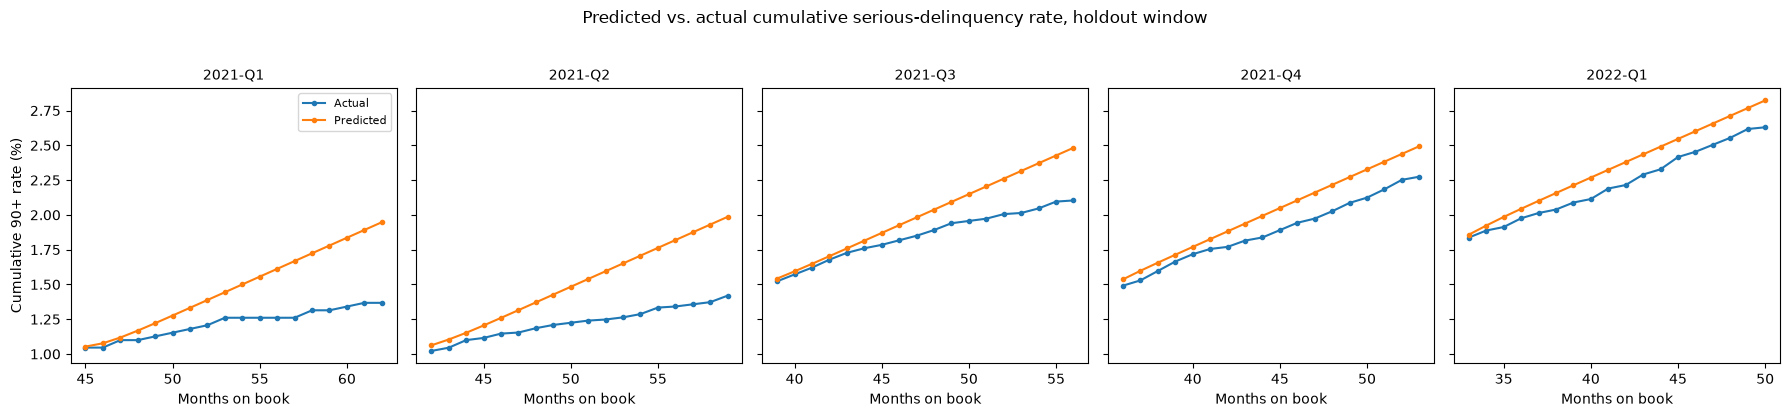

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for ax, cohort in zip(axes, REAL_COHORTS):
    sub = results[results.cohort == cohort]
    ax.plot(sub.months_on_book, sub.actual * 100, label="Actual", marker='o', markersize=3)
    ax.plot(sub.months_on_book, sub.predicted * 100, label="Predicted", marker='o', markersize=3)
    ax.set_title(cohort.strftime('%Y-Q') + str((cohort.month-1)//3+1), fontsize=10)
    ax.set_xlabel("Months on book")
axes[0].set_ylabel("Cumulative 90+ rate (%)")
axes[0].legend(fontsize=8)
plt.suptitle("Predicted vs. actual cumulative serious-delinquency rate, holdout window", y=1.03)
plt.tight_layout()
plt.show()

## 6. Accuracy: MAE and MAPE

**MAE** (mean absolute error, in rate points) is the primary metric here
— it's directly interpretable ("predictions were off by X percentage
points on average") and isn't distorted by the small base rates involved.

**MAPE** is reported too, but read it carefully: these cumulative rates
start near 1% and only reach ~1.5-2% by the end of the holdout window, so
even a small absolute error translates into a large *relative* error —
MAPE is genuinely noisy at this scale, not a sign the model is
dramatically worse than MAE suggests. This is exactly the kind of
"which metric actually tells you what you think it's telling you" nuance
worth being able to explain — MAPE punishes errors on small denominators
disproportionately, which is precisely the situation here.

In [9]:
print(f"MAE  : {results.abs_err.mean():.5f}  ({results.abs_err.mean()*100:.3f} percentage points)")
print(f"MAPE : {results.ape.dropna().mean():.2%}  (n={results.ape.notna().sum()} points with actual > 0)")
print()
bias = (results.predicted - results.actual).mean()
direction = "OVER-predicts" if bias > 0 else "UNDER-predicts"
print(f"Mean bias (predicted - actual): {bias*100:+.4f} pp  -> the model {direction} serious delinquency, on average")
print()
print("MAE by cohort (percentage points):")
print((results.groupby("cohort").abs_err.mean() * 100).round(3))
print()
print("MAE by horizon month (percentage points, across all 5 cohorts):")
print((results.groupby("horizon_month").abs_err.mean() * 100).round(3))

MAE  : 0.00192  (0.192 percentage points)
MAPE : 12.53%  (n=90 points with actual > 0)

Mean bias (predicted - actual): +0.1920 pp  -> the model OVER-predicts serious delinquency, on average

MAE by cohort (percentage points):
cohort
2021-01-01    0.257
2021-04-01    0.288
2021-07-01    0.157
2021-10-01    0.135
2022-01-01    0.123
Name: abs_err, dtype: float64

MAE by horizon month (percentage points, across all 5 cohorts):
horizon_month
1     0.027
2     0.043
3     0.046
4     0.060
5     0.076
6     0.106
7     0.132
8     0.157
9     0.173
10    0.202
11    0.221
12    0.256
13    0.276
14    0.285
15    0.320
16    0.339
17    0.350
18    0.387
Name: abs_err, dtype: float64


## 7. Roll-rate calibration: training-period matrix vs. what actually happened in the holdout

The cumulative-curve accuracy above is one view. This is a more granular
one: build the **same 5-state transition matrix** two ways — once from
training-period transitions only (what the model assumed going forward),
once from holdout-period transitions only (what actually happened,
out-of-sample) — and compare them cell by cell. This is the calibration
table the module spec asked for, not just one aggregate error number.

In [10]:
holdout_matrix = con.execute(f'''
    with perf as (
        select account_id, months_on_book, delinquency_bucket
        from read_parquet('{PERF}') where performance_month > date '{TRAIN_CUTOFF}'
    ),
    lagged as (
        select account_id, delinquency_bucket as to_bucket,
            lag(delinquency_bucket) over (partition by account_id order by months_on_book) as from_bucket
        from perf
    ),
    transitions as (select from_bucket, to_bucket from lagged where from_bucket is not null),
    counted as (select from_bucket, to_bucket, count(*) as n from transitions group by 1,2)
    select from_bucket, to_bucket, n, round(n::double / sum(n) over (partition by from_bucket), 4) as holdout_rate
    from counted order by from_bucket, to_bucket
''').df()

train_matrix5 = con.execute(f'''
    with perf as (
        select account_id, months_on_book, delinquency_bucket
        from read_parquet('{PERF}') where performance_month <= date '{TRAIN_CUTOFF}'
    ),
    lagged as (
        select account_id, delinquency_bucket as to_bucket,
            lag(delinquency_bucket) over (partition by account_id order by months_on_book) as from_bucket
        from perf
    ),
    transitions as (select from_bucket, to_bucket from lagged where from_bucket is not null),
    counted as (select from_bucket, to_bucket, count(*) as n from transitions group by 1,2)
    select from_bucket, to_bucket, n as train_n, round(n::double / sum(n) over (partition by from_bucket), 4) as train_rate
    from counted order by from_bucket, to_bucket
''').df()

calib = train_matrix5.merge(holdout_matrix, on=["from_bucket", "to_bucket"], how="outer").fillna(0)
calib["rate_diff_pp"] = (calib.holdout_rate - calib.train_rate) * 100
calib = calib.sort_values(["from_bucket", "to_bucket"])
print(calib.to_string(index=False))

     from_bucket        to_bucket  train_n  train_rate      n  holdout_rate  rate_diff_pp
120+/Charged-Off 120+/Charged-Off     2708      0.8570   1973        0.9130          5.60
120+/Charged-Off        30-59 DPD       39      0.0123     18        0.0083         -0.40
120+/Charged-Off        60-89 DPD       23      0.0073     11        0.0051         -0.22
120+/Charged-Off       90-119 DPD       18      0.0057     22        0.0102          0.45
120+/Charged-Off          Current      372      0.1177    137        0.0634         -5.43
       30-59 DPD 120+/Charged-Off       30      0.0030     11        0.0018         -0.12
       30-59 DPD        30-59 DPD     3233      0.3235   2632        0.4284         10.49
       30-59 DPD        60-89 DPD     1379      0.1380    985        0.1603          2.23
       30-59 DPD       90-119 DPD       11      0.0011      6        0.0010         -0.01
       30-59 DPD          Current     5341      0.5344   2510        0.4085        -12.59
       60-

**This is the most interesting finding in the whole notebook.** The
`Current` row is essentially frozen between training and holdout (huge
sample — 1.7M+ observations — barely moves). But look at `30-59 DPD`:
the cure rate back to `Current` **drops from 53.4% to 40.9%** between the
training window and the holdout window, while staying in `30-59 DPD`
**rises from 32.4% to 42.8%**. `60-89 DPD -> Current` similarly drops
(23.1% -> 16.9%).

**Read**: early-stage delinquencies cured noticeably *less often* during
the holdout period (late 2024 - early 2026) than during the training
window (2021-2024). That's a genuine, real-world macro/rate-environment
effect the blended, time-invariant matrix this notebook builds has no way
to see coming — which is *exactly* the kind of thing a production model's
macro overlay exists to address (see `dbt/models/credit_risk/README.md`'s
"what a real model adds on top" section). This single table is a better,
more concrete answer to "why would you need a macro overlay?" than any
amount of description.

## 8. Secondary sanity check: Synchrony / FRED anchors

**Explicitly a directional plausibility check, not a validation** — this
compares a mortgage portfolio's serious-delinquency rate against credit-
card charge-off/delinquency benchmarks. Different product types,
different loss definitions (delinquency status vs. a realized net
charge-off), different risk profiles (secured vs. unsecured). The only
thing worth reading off this comparison is *direction and rough
magnitude*, not a precise match.

In [11]:
lifetime = con.execute(f'''
    with perf as (select account_id, delinquency_bucket from read_parquet('{PERF}')),
    flagged as (
        select account_id,
            max(case when delinquency_bucket in {SEVERE} then 1 else 0 end) as ever_severe
        from perf group by 1
    )
    select count(*) as n, sum(ever_severe) as ever_severe_n from flagged
''').df()
mortgage_rate = lifetime.ever_severe_n[0] / lifetime.n[0]

synchrony_nco_rate = 0.0542   # Synchrony disclosed net charge-off rate, Q1 2026
fred_card_delinquency_rate = 0.029  # FRED DRCCLACBS, Delinquency Rate on Credit Card Loans,
                                     # All Commercial Banks, Q1 2026 (fred.stlouisfed.org/series/DRCCLACBS)

print(f"{'Metric':<55} {'Rate':>8}")
print(f"{'-'*55} {'-'*8}")
print(f"{'This vintage -- lifetime ever-90+ DPD rate (mortgage)':<55} {mortgage_rate:>7.2%}")
print(f"{'FRED -- credit card delinquency rate, all banks (Q1 2026)':<55} {fred_card_delinquency_rate:>7.2%}")
print(f"{'Synchrony -- disclosed net charge-off rate (Q1 2026)':<55} {synchrony_nco_rate:>7.2%}")

Metric                                                      Rate
------------------------------------------------------- --------
This vintage -- lifetime ever-90+ DPD rate (mortgage)     2.01%
FRED -- credit card delinquency rate, all banks (Q1 2026)   2.90%
Synchrony -- disclosed net charge-off rate (Q1 2026)      5.42%


**Directionally as expected**: the mortgage sample's serious-
delinquency rate sits well below both credit-card benchmarks — secured,
lower-risk lending should, and does, show a lower loss-adjacent rate than
unsecured revolving credit. Worth noting the FRED figure is itself a
*delinquency* rate (past-due, not yet written off) while Synchrony's is a
*realized net charge-off* rate — even within "credit cards," those two
numbers aren't measuring quite the same thing, which is the whole point
of labeling this a plausibility check rather than a validation.

## 9. Plain-language read: did the methodology hold up?

**Mostly yes, with one real, explainable gap.**

- The core mechanic — LAG-based roll-rate matrix, Markov roll-forward,
  cumulative vintage-curve tracking — produced forecasts within roughly
  **0.19 percentage points (MAE)** of what actually happened on a real,
  50,000-loan mortgage vintage, across 5 cohorts and up to 18 months of
  genuine out-of-sample holdout. For a first-pass, non-segmented, blended
  matrix, that's a solid result — the technique is not fundamentally
  broken.
- MAPE (~12.5%) looks worse than MAE in isolation, but that's mostly an
  artifact of small base rates (~1-2%), not a sign the methodology is
  unreliable — see the discussion in section 6.
- The **real gap**: the underlying transition matrix isn't
  time-stable. Cure rates from early-stage delinquency measurably
  worsened between the training window and the holdout window (section
  7) — a genuine macro/rate-environment shift the blended matrix has no
  way to anticipate. That's not a bug in the SQL; it's the actual,
  correct behavior of a model that only knows the past. It's also
  *exactly* the reason production CECL models carry macro overlays and
  don't just extrapolate a single historical matrix forward indefinitely.
- One real bug was caught and fixed while building this notebook (see
  section 5's code comment): the first draft of the "already reached
  severe delinquency" base rate used each account's *current* bucket at
  the cutoff snapshot instead of whether it had *ever* reached severe
  delinquency by that point — silently undercounting accounts that
  cured before the snapshot, and producing a large, misleading
  under-prediction bias that had nothing to do with the model and
  everything to do with the aggregation query. Worth being able to talk
  through in an interview: catching *why* a number looked wrong, not
  just that it looked wrong.

**Bottom line**: the vintage-curve / roll-rate methodology transfers
reasonably well from synthetic data to a real mortgage panel — the
cumulative forecast is close, the mechanics are sound — but the backtest
surfaces the textbook reason production models need more than one static
matrix: cure/roll behavior genuinely drifts with the macro environment,
and a blended time-invariant matrix can't see that coming on its own.